# 0. Setup

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('../data/processed.csv')

In [4]:
df.shape

(48790, 15)

In [5]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Unknown,103497,Some-college,10,Never-married,Unknown,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48785,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48786,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48787,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48788,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 48790 entries, 0 to 48789
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48790 non-null  int64
 1   workclass       48790 non-null  str  
 2   fnlwgt          48790 non-null  int64
 3   education       48790 non-null  str  
 4   education-num   48790 non-null  int64
 5   marital-status  48790 non-null  str  
 6   occupation      48790 non-null  str  
 7   relationship    48790 non-null  str  
 8   race            48790 non-null  str  
 9   sex             48790 non-null  str  
 10  capital-gain    48790 non-null  int64
 11  capital-loss    48790 non-null  int64
 12  hours-per-week  48790 non-null  int64
 13  native-country  48790 non-null  str  
 14  income          48790 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48790.000000,48790,4.879000e+04,48790,48790.000000,48790,48790,48790,48790,48790,48790.000000,48790.000000,48790.000000,48790,48790
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33860,NaN,15770,NaN,22366,6165,19703,41714,32614,NaN,NaN,NaN,43792,37109
mean,38.652798,NaN,1.896690e+05,NaN,10.078807,NaN,NaN,NaN,NaN,NaN,1080.217688,87.595573,40.425886,NaN,NaN
std,13.708493,NaN,1.056172e+05,NaN,2.570046,NaN,NaN,NaN,NaN,NaN,7455.905921,403.209129,12.392729,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175550e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781385e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376062e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [7]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

# 1. Understand distribution

Focus on the following numerical features:
- age
- hours-per-week
- capital-gain
- capital-loss

#### Histogram

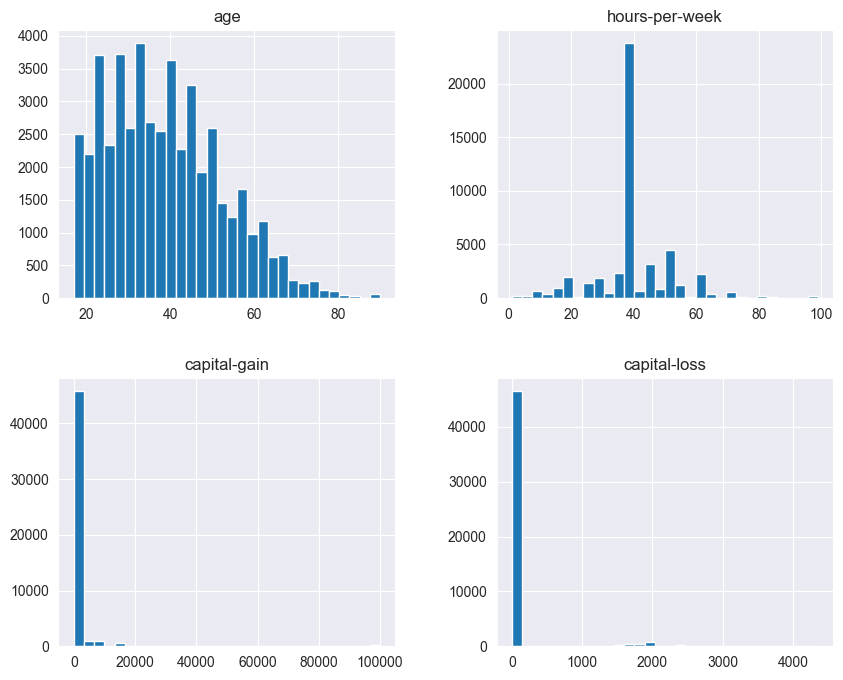

In [8]:
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']

df[num_cols].hist(figsize=(10,8), bins=30)
plt.show()

##### Observations
- The age data shows approximately Gaussian distribution.
- The hour-per-week is peak in the 40 hr/week.
- capital gain and capital loss is peak at 0. (Skewed)

#### Boxplots


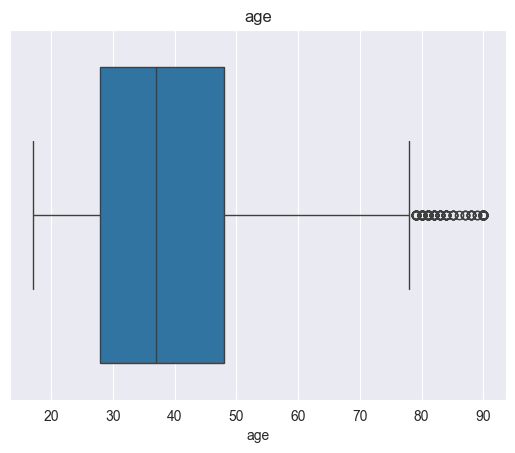

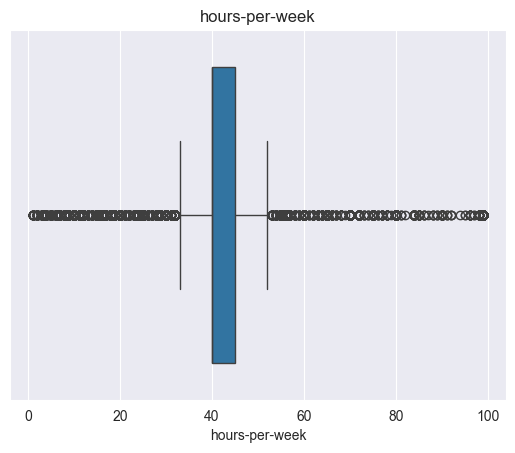

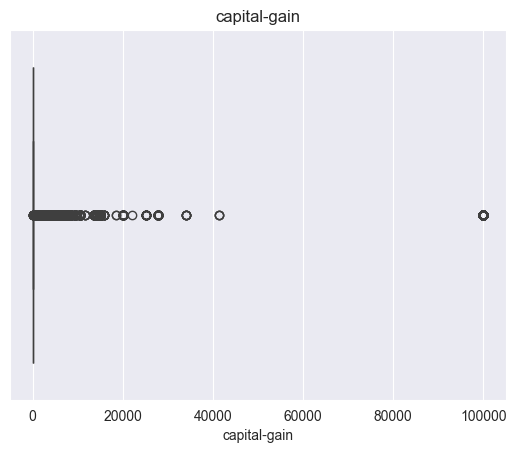

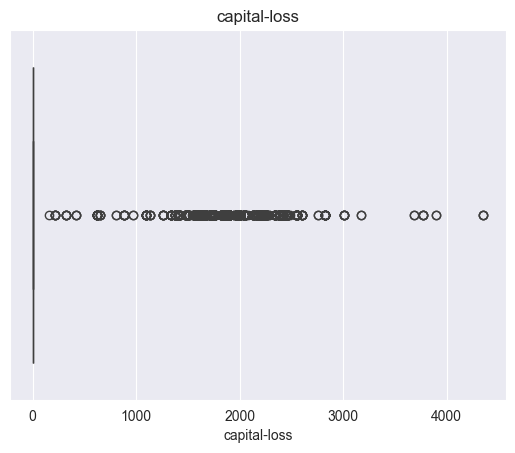

In [9]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

#### Categorical features

The main focus on :
- workclass
- education
- occupation
- marital-status

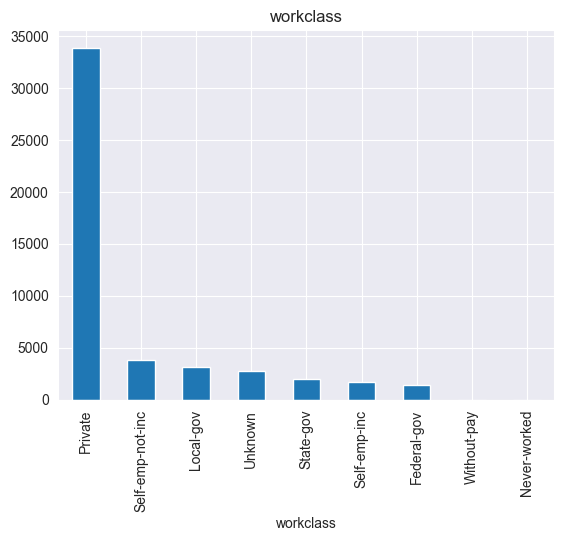

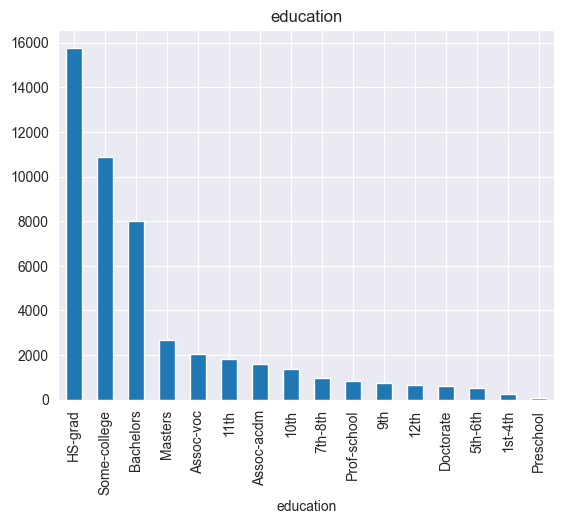

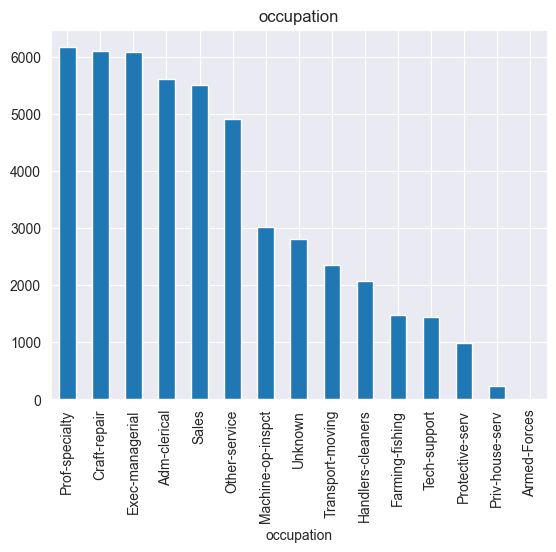

In [10]:
for col in ['workclass', 'education', 'occupation']:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

##### Observations
- The working class is mostly private.
- Most of the data has bachelors or more.
- The occupation is predominantly are : prof-specialty, Craft-repair,Exec-managerial, Adam-clerical

# 2. Correrlation analysis

Note: Most of the data are categorical in this dataset that is why the coorelation is limited.

##### Numerical correlation heatmap

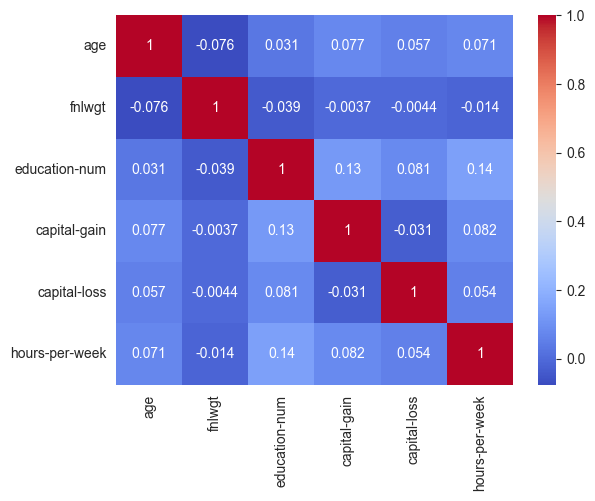

In [11]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

##### Scatter plot

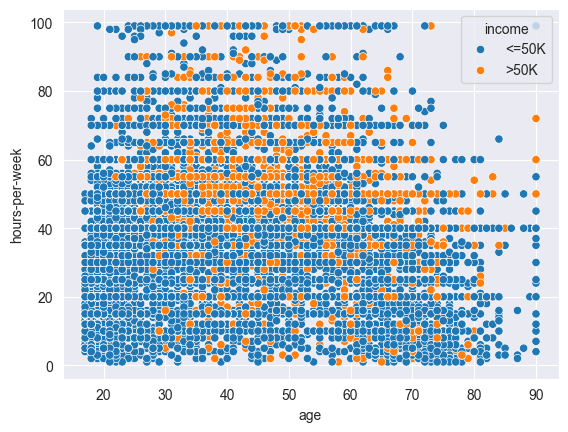

In [12]:
sns.scatterplot(x='age', y='hours-per-week', hue='income', data=df)
plt.show()

In [13]:
df.groupby('income')[['age', 'hours-per-week']].mean()

,age,hours-per-week
income,,
<=50K,36.882751,38.842976
>50K,44.276004,45.454584


# 3. Class imbalance checks

In [14]:
df['income'].value_counts()

income
<=50K    37109
>50K     11681
Name: count, dtype: int64

# 4. Identify patterns, trends, anomalies

#### Income Vs Categorical features.

##### Education Vs Income

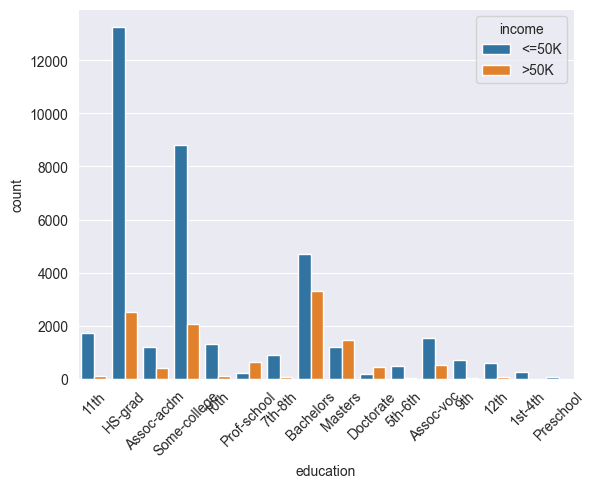

In [15]:
sns.countplot(x='education', hue='income', data=df)
plt.xticks(rotation=45)
plt.show()

##### Occupation Vs Income

##### Occupation Vs Income

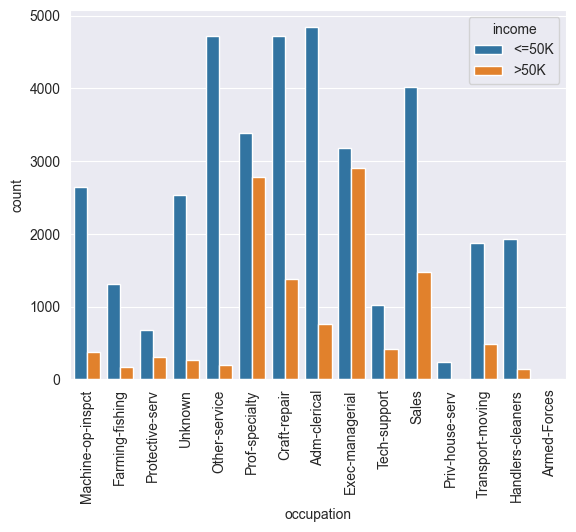

In [16]:
sns.countplot(x='occupation', hue='income', data=df)
plt.xticks(rotation=90)
plt.show()

##### Workclass Vs Income

##### Workclass Vs Income

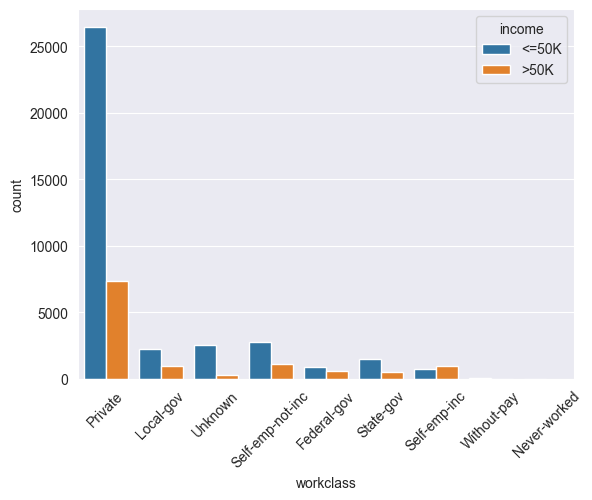

In [17]:
sns.countplot(x='workclass', hue='income', data=df)
plt.xticks(rotation=45)
plt.show()

#### Numerical Vs Target

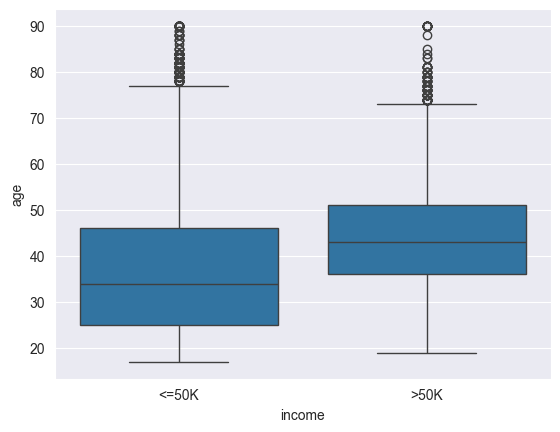

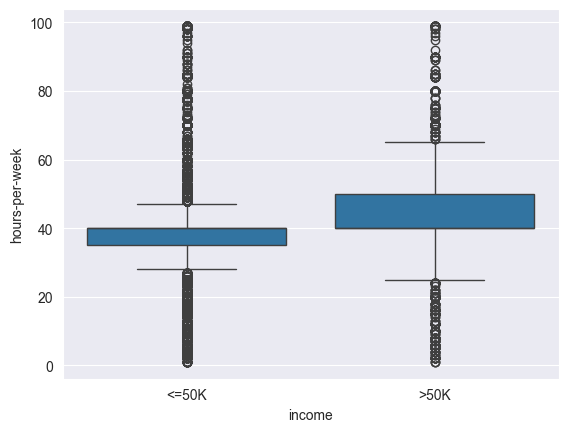

In [19]:
sns.boxplot(x='income', y='age', data=df)
plt.show()

sns.boxplot(x='income', y='hours-per-week', data=df)
plt.show()

##### Observation
- People who are having higher income their salary is more which is obvious.
- Higher income is directly correlated with the more hours-per-week

#### Capital gain signal

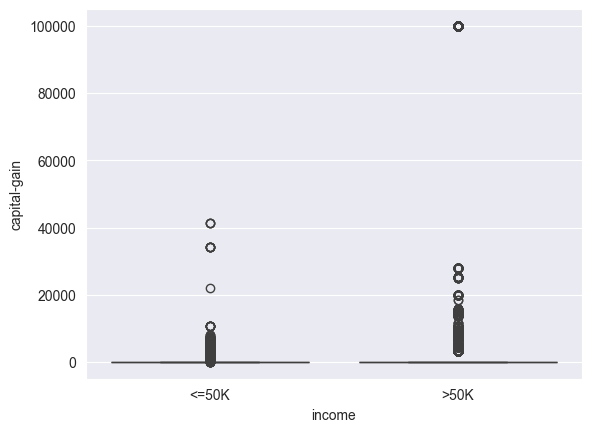

In [20]:
sns.boxplot(x='income', y='capital-gain', data=df)
plt.show()

##### Observation
- More income is directly related to higher capital gains.

# 5. Anolmaly detection

In [21]:
df[df['hours-per-week'] > 90]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
384,29,Private,211208,11th,7,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,99,United-States,>50K
723,35,Self-emp-not-inc,28987,9th,5,Married-civ-spouse,Craft-repair,Husband,Amer-Indian-Eskimo,Male,0,0,96,United-States,<=50K
900,37,Private,112158,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,7688,0,99,United-States,>50K
1120,31,Local-gov,378426,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,99,Columbia,<=50K
1155,48,Unknown,117054,5th-6th,3,Divorced,Unknown,Not-in-family,White,Male,0,0,99,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47912,43,Private,266324,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,1902,99,United-States,>50K
47930,43,Self-emp-not-inc,163108,Some-college,10,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,99,United-States,<=50K
48080,21,Self-emp-not-inc,304602,Assoc-voc,11,Never-married,Farming-fishing,Own-child,White,Male,0,0,98,United-States,<=50K
48698,58,Self-emp-inc,181974,Doctorate,16,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,99,Unknown,<=50K


# 6. Domain reasoning

### Observations
- Education: Education helps people to develop diverse skills which directly enables people to have higher income.
- Occupation: Income is directly related to the higher value of jobs. Therefore, the occupation has direct correlation.
- Capital gain: People with higher income will prompt to invest more, that is why the capital gain is significant.
- Work hours: The working hour means the efforts put on the work. More working hours means higher income and this is clearly visible in the dataset.